In [0]:
#!pwd

In [0]:
#!wget https://repo.anaconda.com/miniconda/Miniconda2-4.5.4-Linux-x86_64.sh && bash /content/Miniconda2-4.5.4-Linux-x86_64.sh# -bfp /usr/local

In [0]:
#!conda create --yes --name py36
#!source activate py36

In [0]:
#import sys
#sys.path.append(#'/usr/local/lib/python3.6/site-packages')

In [0]:
#!conda config --add channels defaults
#!conda config --add channels conda-forge
#!conda config --add channels bioconda
#!conda install --yes deepsvr --force --no-deps

In [0]:
#!deepsvr --help

In [0]:
! git clone https://github.com/griffithlab/DeepSVR.git

Cloning into 'DeepSVR'...
remote: Enumerating objects: 4, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 2450 (delta 0), reused 1 (delta 0), pack-reused 2446
Receiving objects: 100% (2450/2450), 165.54 MiB | 25.54 MiB/s, done.
Resolving deltas: 100% (1440/1440), done.
Checking out files: 100% (188/188), done.


In [0]:

import numpy as np
import pandas as pd
import os
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_predict
from sklearn import preprocessing
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns
from itertools import cycle

from DeepSVR.analysis_utils.ClassifierPlots import create_reliability_diagram, create_roc_curve, create_feature_importance_plot
from DeepSVR.analysis_utils.Analysis import print_accuracy_and_classification_report, predict_classes, get_somatic_error_type

sns.set_style("white")
sns.set_context('poster')

/usr/local/lib/python3.6/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [0]:
# Pull in training data
training_data = pd.read_pickle('DeepSVR/data/training_data_preprocessed.pkl')
training_data.sort_index(axis=1, inplace=True)
# Remove AML31 case
aml31_training = training_data[training_data.index.str.contains('fSsMNn1DZ3AIDGk=')]
training_data = training_data[~training_data.index.str.contains('fSsMNn1DZ3AIDGk=')]
# Show the calls associate with training data
training_data.groupby('call').size()

call
a    10643
f     8854
g     3122
s    18381
dtype: int64

In [0]:
training_data

# Somatic, ambigous, fail classifier

In [0]:
# Re-label the germline calls as failed calls
three_class = training_data.replace('g','f')
three_class.sort_index(axis=1, inplace=True)

In [0]:
# fix random seed for reproducibility
seed = 7
np.random.seed(seed)
# Get labels for training data
Y = three_class.call.values
# Get training data as numpy array
X = training_data.drop(['call'], axis=1).astype(float).values
# Get labels for training data
Y = three_class.call.values
# Get training data as numpy array
X = training_data.drop(['call'], axis=1).astype(float).values

In [0]:
# Split the data for cross-validation
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.33, random_state=seed)
# Determine shape of training data features for cross-validation
X_train.shape

(27470, 71)

In [0]:
# Determine shape of training data calls for cross-validation
Y_train.shape

(27470,)



```python

# Set parameters for the Random Forest Model
kfold = KFold(n_splits=10, shuffle=True, random_state=seed)
enc = preprocessing.MultiLabelBinarizer()
Y_one_hot = enc.fit_transform(Y_train)
# Perform cross validation and pull AUC for various splits
auc = []
for n in [100, 1000, 10000]:
    est = RandomForestClassifier(n_estimators=n, max_features=8,n_jobs=-1, 
                                 oob_score=True)
    probs = cross_val_predict(est, X_train, Y_train, cv=kfold, method='predict_proba')
    temp_auc = []
    for j in range(Y_one_hot.shape[1]):
        temp_auc.append(metrics.roc_auc_score(Y_one_hot[:, j], probs[:, j]))
    auc.append(temp_auc)
    print('Test AUC for {0} trees: '.format(n), temp_auc)
    print('---------------------------------------------------------')
```



#  SVM linear

In [0]:
%reset -f

In [0]:

import numpy as np
import pandas as pd
import os
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_predict
from sklearn import preprocessing
from sklearn import metrics
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns
from itertools import cycle

from DeepSVR.analysis_utils.ClassifierPlots import create_reliability_diagram, create_roc_curve, create_feature_importance_plot
from DeepSVR.analysis_utils.Analysis import print_accuracy_and_classification_report, predict_classes, get_somatic_error_type

sns.set_style("white")
sns.set_context('poster')

# training a linear SVM classifier 
from sklearn.svm import SVC 

## Data Pre-processing

In [0]:

# Pull in training data
training_data = pd.read_pickle('DeepSVR/data/training_data_preprocessed.pkl')
training_data.sort_index(axis=1, inplace=True)
# Remove validation sample
training_data = training_data[~training_data.index.str.contains('fSsMNn1DZ3AIDGk=')]
training_data

,call,disease_AML,disease_GST,disease_MPNST,disease_SCLC,disease_breast,disease_colorectal,disease_glioblastoma,disease_lymphoma,disease_melanoma,normal_VAF,normal_depth,normal_other_bases_count,normal_ref_avg_basequality,normal_ref_avg_clipped_length,normal_ref_avg_distance_to_effective_3p_end,normal_ref_avg_distance_to_q2_start_in_q2_reads,normal_ref_avg_mapping_quality,normal_ref_avg_num_mismaches_as_fraction,normal_ref_avg_pos_as_fraction,normal_ref_avg_se_mapping_quality,normal_ref_avg_sum_mismatch_qualities,normal_ref_count,normal_ref_num_minus_strand,normal_ref_num_plus_strand,normal_ref_num_q2_containing_reads,normal_var_avg_basequality,normal_var_avg_clipped_length,normal_var_avg_distance_to_effective_3p_end,normal_var_avg_distance_to_q2_start_in_q2_reads,normal_var_avg_mapping_quality,normal_var_avg_num_mismaches_as_fraction,normal_var_avg_pos_as_fraction,normal_var_avg_se_mapping_quality,normal_var_avg_sum_mismatch_qualities,normal_var_count,normal_var_num_minus_strand,normal_var_num_plus_strand,normal_var_num_q2_containing_reads,reviewer_1,reviewer_2,reviewer_3,reviewer_4,tumor_VAF,tumor_depth,tumor_other_bases_count,tumor_ref_avg_basequality,tumor_ref_avg_clipped_length,tumor_ref_avg_distance_to_effective_3p_end,tumor_ref_avg_distance_to_q2_start_in_q2_reads,tumor_ref_avg_mapping_quality,tumor_ref_avg_num_mismaches_as_fraction,tumor_ref_avg_pos_as_fraction,tumor_ref_avg_se_mapping_quality,tumor_ref_avg_sum_mismatch_qualities,tumor_ref_count,tumor_ref_num_minus_strand,tumor_ref_num_plus_strand,tumor_ref_num_q2_containing_reads,tumor_var_avg_basequality,tumor_var_avg_clipped_length,tumor_var_avg_distance_to_effective_3p_end,tumor_var_avg_distance_to_q2_start_in_q2_reads,tumor_var_avg_mapping_quality,tumor_var_avg_num_mismaches_as_fraction,tumor_var_avg_pos_as_fraction,tumor_var_avg_se_mapping_quality,tumor_var_avg_sum_mismatch_qualities,tumor_var_count,tumor_var_num_minus_strand,tumor_var_num_plus_strand,tumor_var_num_q2_containing_reads
fSsFJH1EY3AKAWF2 BER9Q2JBY3EPAWUcZUpOaAZCc0MRSRU=,a,1,0,0,0,0,0,0,0,0,0.000000,0.008968,0.000000,0.952927,0.792857,0.383838,0.278351,0.485333,0.090909,0.56,0.492973,0.114673,0.008974,0.010887,0.005475,0.004793,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1,0,0,0,0.266667,0.001308,0.000000,0.974390,0.793651,0.494949,0.571429,0.434167,0.08,0.57,0.261000,0.142866,0.001002,0.001105,0.000902,0.000794,0.894878,0.793651,0.414141,0.377551,0.192667,0.057692,0.62,0.140667,0.215676,0.000990,0.001075,0.000806,0.000735
fSsFJH1EY3AKAWF2 BEV9RGJDY3UABGEcYkpMaAJNdkcXSQY=,s,1,0,0,0,0,0,0,0,0,0.011494,0.019029,0.000000,0.864146,0.780635,0.484848,0.494845,0.983500,0.000000,0.50,0.994865,0.006272,0.018822,0.016935,0.017208,0.017117,0.878049,0.793651,0.363636,0.367347,1.000000,0.022727,0.76,0.616667,0.067925,0.001495,0.000000,0.003831,0.003497,1,0,0,0,0.584615,0.004250,0.000000,0.828780,0.739603,0.414141,0.438776,0.744833,0.12,0.46,0.548333,0.002040,0.001845,0.001243,0.002435,0.002185,0.883902,0.791508,0.474747,0.479592,1.000000,0.019231,0.51,0.614833,0.074597,0.007054,0.006450,0.007258,0.006860
fSsFJH1EY3AKAWF2 BEV9RGJDZ3oMAWMcYkpMbA1Bc0UTSQY=,s,1,0,0,0,0,0,0,0,0,0.000000,0.023185,0.000000,0.905366,0.790476,0.454545,0.443299,0.996333,0.000000,0.53,1.000000,0.002357,0.023200,0.023387,0.018772,0.017460,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1,0,0,0,0.417219,0.003291,0.000000,0.903902,0.789762,0.454545,0.397959,0.987500,0.00,0.53,0.612833,0.004759,0.002005,0.002624,0.001398,0.001350,0.871463,0.781587,0.444444,0.408163,1.000000,0.019231,0.53,0.616667,0.078946,0.003898,0.004192,0.003226,0.003553
fSsFJH1EY3AKAWF2 BEV9QmFCZXsLA2IcZElNbgxGcUN9SQY=,a,1,0,0,0,0,0,0,0,0,0.000000,0.001750,0.000000,0.838537,0.733175,0.494949,0.649485,0.731333,0.227273,0.56,0.797297,0.200983,0.001751,0.000403,0.002738,0.002396,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000

### Feature Scaling

In [0]:
### before

# Show the calls associate with training data
print(training_data.groupby('call').size())

### after 

# Re-label the germline calls as failed calls
three_class = training_data.replace('g', 'f')
print(three_class.call.value_counts())

# Get Labels
from sklearn import preprocessing
leble_encoder = preprocessing.LabelEncoder()
leble_encoder.fit(three_class.call)
print(list(leble_encoder.classes_))
Y= leble_encoder.transform(three_class.call)
# leble_encoder.inverse_transform([2, 2, 1])
#Y = pd.get_dummies(three_class.call).astype(float).values

# Get training data as numpy array
X = training_data.drop('call', axis=1).astype(float).values


call
a    10643
f     8854
g     3122
s    18381
dtype: int64
s    18381
f    11976
a    10643
Name: call, dtype: int64
['a', 'f', 's']


In [0]:
print(Y)

[0 2 2 ... 2 2 1]


In [0]:
print(three_class.call)

fSsFJH1EY3AKAWF2 BER9Q2JBY3EPAWUcZUpOaAZCc0MRSRU=        a
fSsFJH1EY3AKAWF2 BEV9RGJDY3UABGEcYkpMaAJNdkcXSQY=        s
fSsFJH1EY3AKAWF2 BEV9RGJDZ3oMAWMcYkpMbA1Bc0UTSQY=        s
fSsFJH1EY3AKAWF2 BEV9QmFCZXsLA2IcZElNbgxGcUN9SQY=        a
fSsFJH1EY3AKAWF2 BEZ9RmNHanUOA2YBfElLaQ1DcEFnRwZ8eg==    a
                                                        ..
fSsJJ31OYnIJBWE= bU5zQ2lFYHQODHwFZUFKawNDfjBuIw==        s
fSsJJ31OYnIJBWE= bU5yRGREYHcBAHwEYkxLawBMciNuNA==        s
fSsJJ31OYnIJBWE= bU5yQmFGZHcKDHwEZElJbwBHfiNuNg==        s
fSsJJ31OYnIJBWE= bU5xTmVHY3cMDXwHaE1IaABBfzBuNg==        s
fSsJJ31OYnIJBWE= bE52RGROZHYPAXwAYkxBbwFCcjYTSX8=        f
Name: call, Length: 41000, dtype: object


### Splitting the dataset into the Training set and Test set

In [0]:

# fix random seed for reproducibility
seed = 7
np.random.seed(seed)


# Split the data for cross-validation
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.33, random_state=seed)

# Determine shape of training data features for cross-validation
print(X_train.shape)

# Determine shape of training data features for cross-validation
print(Y_train.shape)

(27470, 71)
(27470,)


## Algorithms

### Fitting SVM to the Training set

In [0]:
## Use GridsearchCV
from sklearn.model_selection import GridSearchCV 
  
# defining parameter range 
# Set the parameters by cross-validation
#tuned_parameters = [{'kernel': ['rbf'],
#                     'C': [0.001, 0.01, 0.1, 1,  10, 25, 50, 100 , 1000]},
#                    {'kernel': ['sigmoid'],
#                     'C': [0.001, 0.01, 0.1, 1, 10, 25, 50, 100, 1000]},
#                    {'kernel': ['linear'], 'C': [0.001, 0.01, 0.1,1, 10, 25, 50, 100, 1000]}
#                   ]
tuned_parameters = [
                    {'kernel': ['linear'], 'C': [0.1, 1,10, 50, 100]}
                   ]

svm_model = GridSearchCV(SVC(probability=True), tuned_parameters, refit = True, cv=10, verbose = 3,n_jobs=1) 

#svm_model_linear = SVC(kernel = 'linear', C = 1,probability=True ).fit(X_train, Y_train) 

In [0]:
svm_model.fit(X_train, Y_train) 

Fitting 10 folds for each of 5 candidates, totalling 50 fits
[CV] C=0.1, kernel=linear ............................................


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


[CV] ................ C=0.1, kernel=linear, score=0.826, total= 2.5min
[CV] C=0.1, kernel=linear ............................................


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  2.5min remaining:    0.0s


[CV] ................ C=0.1, kernel=linear, score=0.817, total= 2.5min
[CV] C=0.1, kernel=linear ............................................


[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:  5.0min remaining:    0.0s


[CV] ................ C=0.1, kernel=linear, score=0.834, total= 2.4min
[CV] C=0.1, kernel=linear ............................................
[CV] ................ C=0.1, kernel=linear, score=0.824, total= 2.4min
[CV] C=0.1, kernel=linear ............................................
[CV] ................ C=0.1, kernel=linear, score=0.846, total= 2.4min
[CV] C=0.1, kernel=linear ............................................
[CV] ................ C=0.1, kernel=linear, score=0.826, total= 2.4min
[CV] C=0.1, kernel=linear ............................................
[CV] ................ C=0.1, kernel=linear, score=0.828, total= 2.4min
[CV] C=0.1, kernel=linear ............................................
[CV] ................ C=0.1, kernel=linear, score=0.822, total= 2.3min
[CV] C=0.1, kernel=linear ............................................
[CV] ................ C=0.1, kernel=linear, score=0.839, total= 2.3min
[CV] C=0.1, kernel=linear ............................................
[CV] .

[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed: 169.5min finished


GridSearchCV(cv=10, error_score=nan,
             estimator=SVC(C=1.0, break_ties=False, cache_size=200,
                           class_weight=None, coef0=0.0,
                           decision_function_shape='ovr', degree=3,
                           gamma='scale', kernel='rbf', max_iter=-1,
                           probability=True, random_state=None, shrinking=True,
                           tol=0.001, verbose=False),
             iid='deprecated', n_jobs=1,
             param_grid=[{'C': [0.1, 1, 10, 50, 100], 'kernel': ['linear']}],
             pre_dispatch='2*n_jobs', refit=True, return_train_score=False,
             scoring=None, verbose=3)

In [0]:
# print best parameter after tuning 
print(svm_model.best_params_) 
  
# print how our model looks after hyper-parameter tuning 
print(svm_model.best_estimator_) 

{'C': 100, 'kernel': 'linear'}
SVC(C=100, break_ties=False, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma='scale', kernel='linear',
    max_iter=-1, probability=True, random_state=None, shrinking=True, tol=0.001,
    verbose=False)


In [0]:
SVM_best_estimator_ = SVC(C=100, break_ties=False, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma='scale', kernel='rbf',
    max_iter=-1, probability=True, random_state=None, shrinking=True,
    tol=0.001, verbose=False)  #<-- fix probability=True

In [0]:
SVM_best_estimator_.fit(X_train, Y_train) 

In [0]:
import pickle

#
# Create your model here (same as above)
#

# Save to file in the current working directory
pkl_filename ="svm_pickle_model.linear.pkl"
with open(pkl_filename, 'wb') as file:
    pickle.dump(svm_model, file)

In [0]:
# Load from file
import pickle
with open( "svm_pickle_model.linear.pkl", 'rb') as file:
    pickle_model = pickle.load(file)

### Predicting the Test set results

In [0]:
y_pred = pickle_model.best_estimator_.predict(X_test) 

In [0]:

print_accuracy_and_classification_report(Y_test, y_pred)

Cross validation accuracy:
	 0.8413155949741316

Cross validation classification report

              precision    recall  f1-score   support

           0       0.71      0.73      0.72      3454
           1       0.91      0.87      0.89      3961
           2       0.87      0.89      0.88      6115

    accuracy                           0.84     13530
   macro avg       0.83      0.83      0.83     13530
weighted avg       0.84      0.84      0.84     13530



## Evaluation

### Perform cross validation with the entire dataset.

In [0]:
svm_model

GridSearchCV(cv=10, error_score=nan,
             estimator=SVC(C=1.0, break_ties=False, cache_size=200,
                           class_weight=None, coef0=0.0,
                           decision_function_shape='ovr', degree=3,
                           gamma='scale', kernel='rbf', max_iter=-1,
                           probability=True, random_state=None, shrinking=True,
                           tol=0.001, verbose=False),
             iid='deprecated', n_jobs=1,
             param_grid=[{'C': [0.1, 1, 10, 50, 100], 'kernel': ['linear']}],
             pre_dispatch='2*n_jobs', refit=True, return_train_score=False,
             scoring=None, verbose=3)

In [0]:
probability_linear = svm_model.predict_proba(X_train)

In [0]:
probability_linear

array([[1.43610951e-01, 3.97461500e-01, 4.58927550e-01],
       [9.30521357e-02, 2.17559543e-01, 6.89388321e-01],
       [3.36325050e-01, 4.79026422e-01, 1.84648528e-01],
       ...,
       [7.70347759e-01, 8.94647979e-03, 2.20705761e-01],
       [3.01065319e-02, 5.09185843e-04, 9.69384282e-01],
       [9.41638446e-01, 3.60942288e-03, 5.47521313e-02]])

In [0]:
# Save the probabilities in /data folder
np.save('SVM_estimators_27470.linear.npy', probability_linear)

In [0]:
# Set parameters for the Random Forest Model
kfold = KFold(n_splits=10, shuffle=True, random_state=seed)
probabilities = cross_val_predict(SVM_best_estimator_, X_train, Y_train, cv=kfold, method='predict_proba')
#probabilities = cross_val_predict(SVM_best_estimator_, X, Y, cv=kfold, method='predict_proba')

In [0]:
# Save the probabilities in /data folder
np.save('SVM_estimators_27470.npy', probabilities)

In [0]:
probabilities = np.load('SVM_estimators_27470.linear.npy')

 Classification report
 * 'a' = 0
 * 'f' = 1
 * 's' = 2

In [0]:
probabilities

array([[0.08047423, 0.55819008, 0.36133569],
       [0.10759116, 0.1370651 , 0.75534374],
       [0.03996504, 0.94715235, 0.01288261],
       ...,
       [0.48374385, 0.00431558, 0.51194057],
       [0.01239002, 0.00123274, 0.98637724],
       [0.97016039, 0.01160015, 0.01823946]])

In [0]:
# Turn probabilities into a numpy array
predicted = np.array([list(a).index(max(list(a))) for a in list(probabilities)])

# Process predicted numpy array

#predicted_transformed= leble_encoder.inverse_transform(predicted)


In [0]:
# print accuracy report
#print_accuracy_and_classification_report(Y, predicted)
print_accuracy_and_classification_report(Y_train, predicted)

Cross validation accuracy:
	 0.8436112122315254

Cross validation classification report

              precision    recall  f1-score   support

           0       0.75      0.71      0.73      7189
           1       0.91      0.88      0.89      8015
           2       0.85      0.90      0.88     12266

    accuracy                           0.84     27470
   macro avg       0.84      0.83      0.83     27470
weighted avg       0.84      0.84      0.84     27470



Cross validation accuracy:
	 0.8764106297779396

Cross validation classification report

              precision    recall  f1-score   support

           0       0.83      0.73      0.78      7189
           1       0.90      0.92      0.91      8015
           2       0.88      0.93      0.91     12266

    accuracy                           0.88     27470
   macro avg       0.87      0.86      0.87     27470
weighted avg       0.87      0.88      0.87     27470

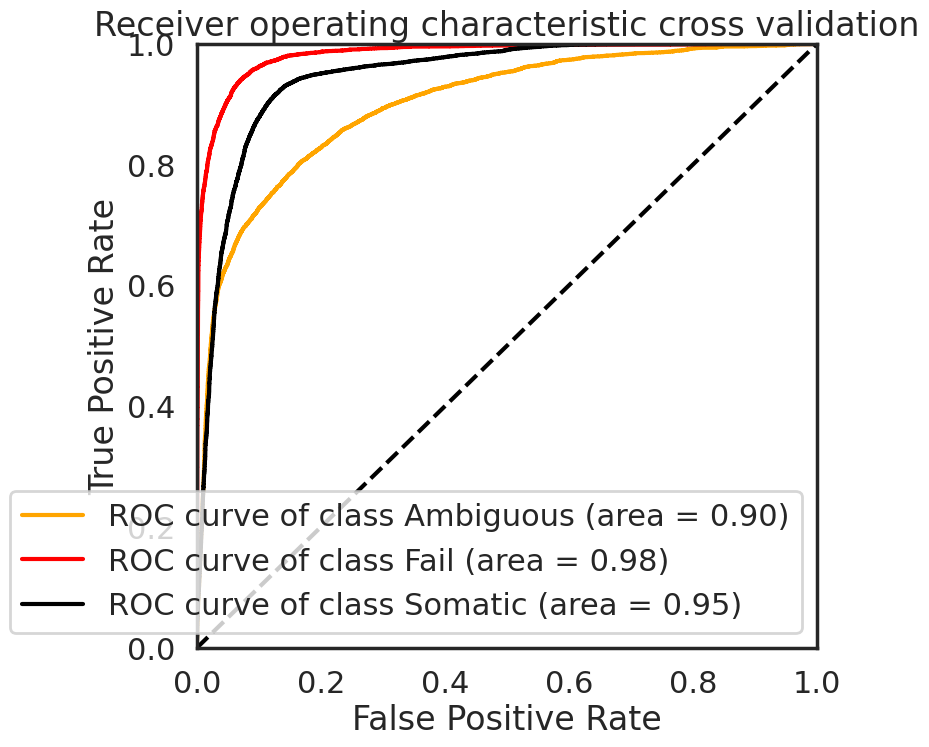

In [0]:
# Plot AUC curves for Logistic Regression Model
class_lookup = {0: 'Ambiguous', 1: 'Fail', 2: 'Somatic'}
fig, ax = plt.subplots(figsize=(8,8),dpi=100)
create_roc_curve( pd.get_dummies(Y_train).astype(float).values, probabilities, class_lookup, 'Receiver operating characteristic cross validation', ax=ax)
#create_roc_curve( pd.get_dummies(three_class.call).astype(float).values, probabilities, class_lookup, 'Receiver operating'
                 #' characteristic cross validation', ax=ax)

confidence intervals +-:  [0.00073403 0.00359147 0.00503807 0.00763118 0.00961352 0.00967088
 0.00776655 0.00525942 0.00418698 0.00174091]


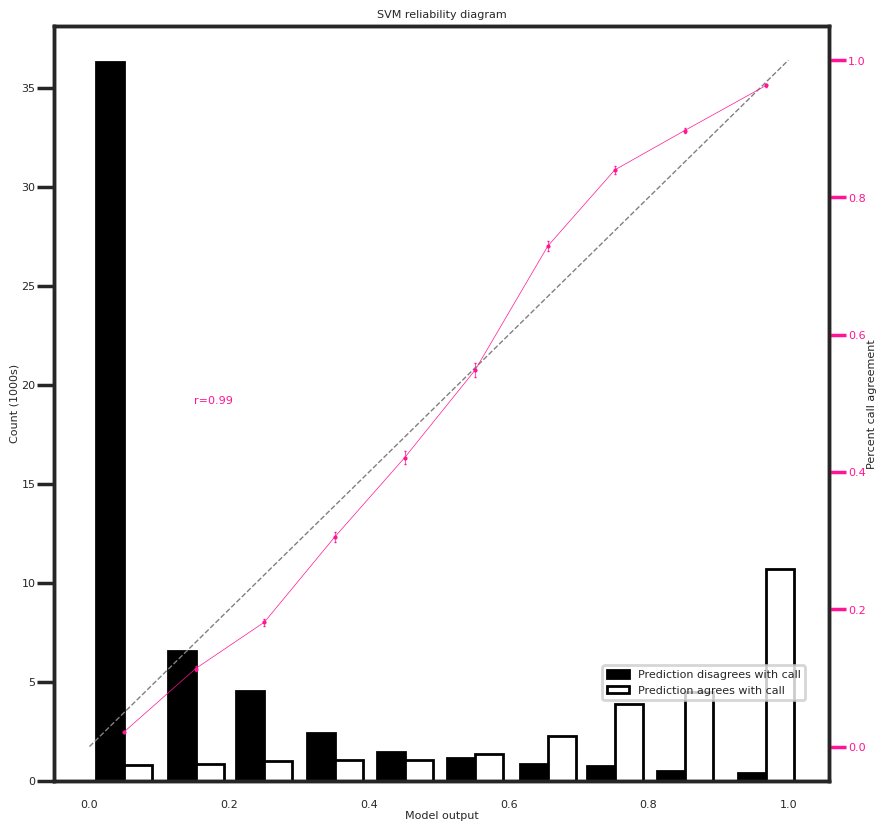

In [0]:
# Plot Reliability Diagrams for Logistic Regression Model
fig, ax = plt.subplots(figsize=(10,10),dpi=100)
lgd = create_reliability_diagram(probabilities,  pd.get_dummies(Y_train).astype(float).values,['Ambiguous','Fail','Somatic'], 'deeppink', 'SVM reliability diagram',
                           ax, True, True, True)
lgd.set_bbox_to_anchor((0.7, .1))

For whole dataset

confidence intervals +-:  [0.00048855 0.00345392 0.00731437 0.00991254 0.01074394 0.01109541
 0.01019337 0.00783881 0.00348391 0.00098083]


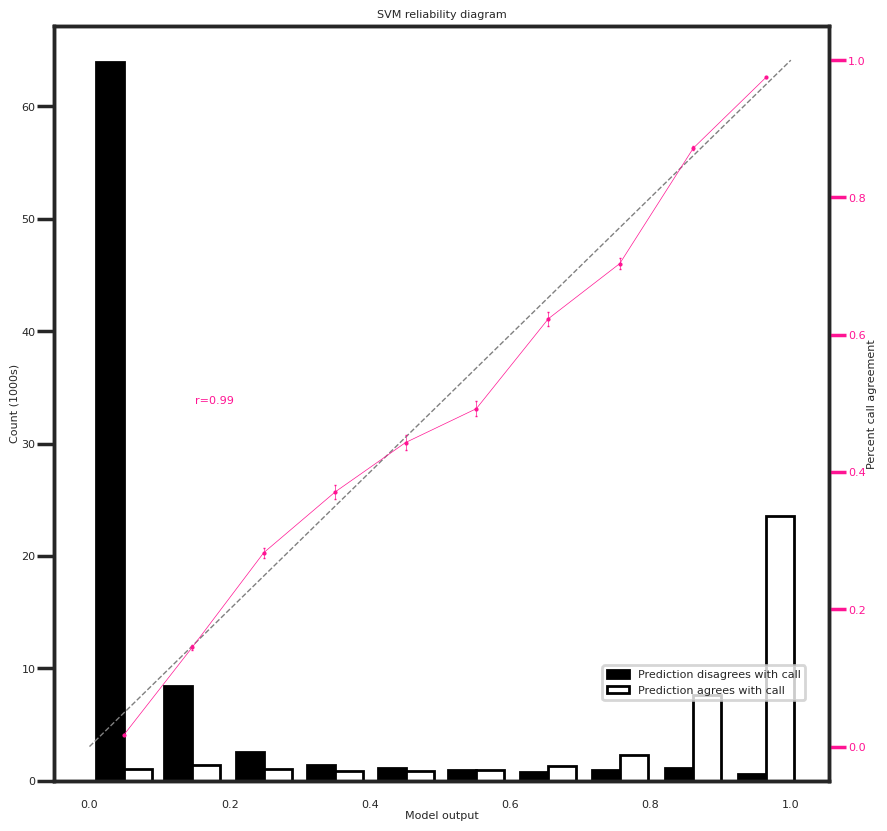

In [0]:
# Plot Reliability Diagrams for Logistic Regression Model
fig, ax = plt.subplots(figsize=(10,10),dpi=100)
lgd = create_reliability_diagram(probabilities,  pd.get_dummies(three_class.call).astype(float)
.values,['Ambiguous','Fail','Somatic'], 'deeppink', 'SVM reliability diagram',
                           ax, True, True, True)
lgd.set_bbox_to_anchor((0.7, .1))

## Important feature

In [0]:
feature_importances

,importance
normal_other_bases_count,7.070353
tumor_ref_num_plus_strand,6.159346
normal_ref_num_plus_strand,5.163759
tumor_var_avg_mapping_quality,2.324465
normal_depth,2.320648
...,...
normal_var_num_plus_strand,-3.657415
normal_ref_num_q2_containing_reads,-8.693012
normal_var_count,-9.483744
tumor_other_bases_count,-10.324065


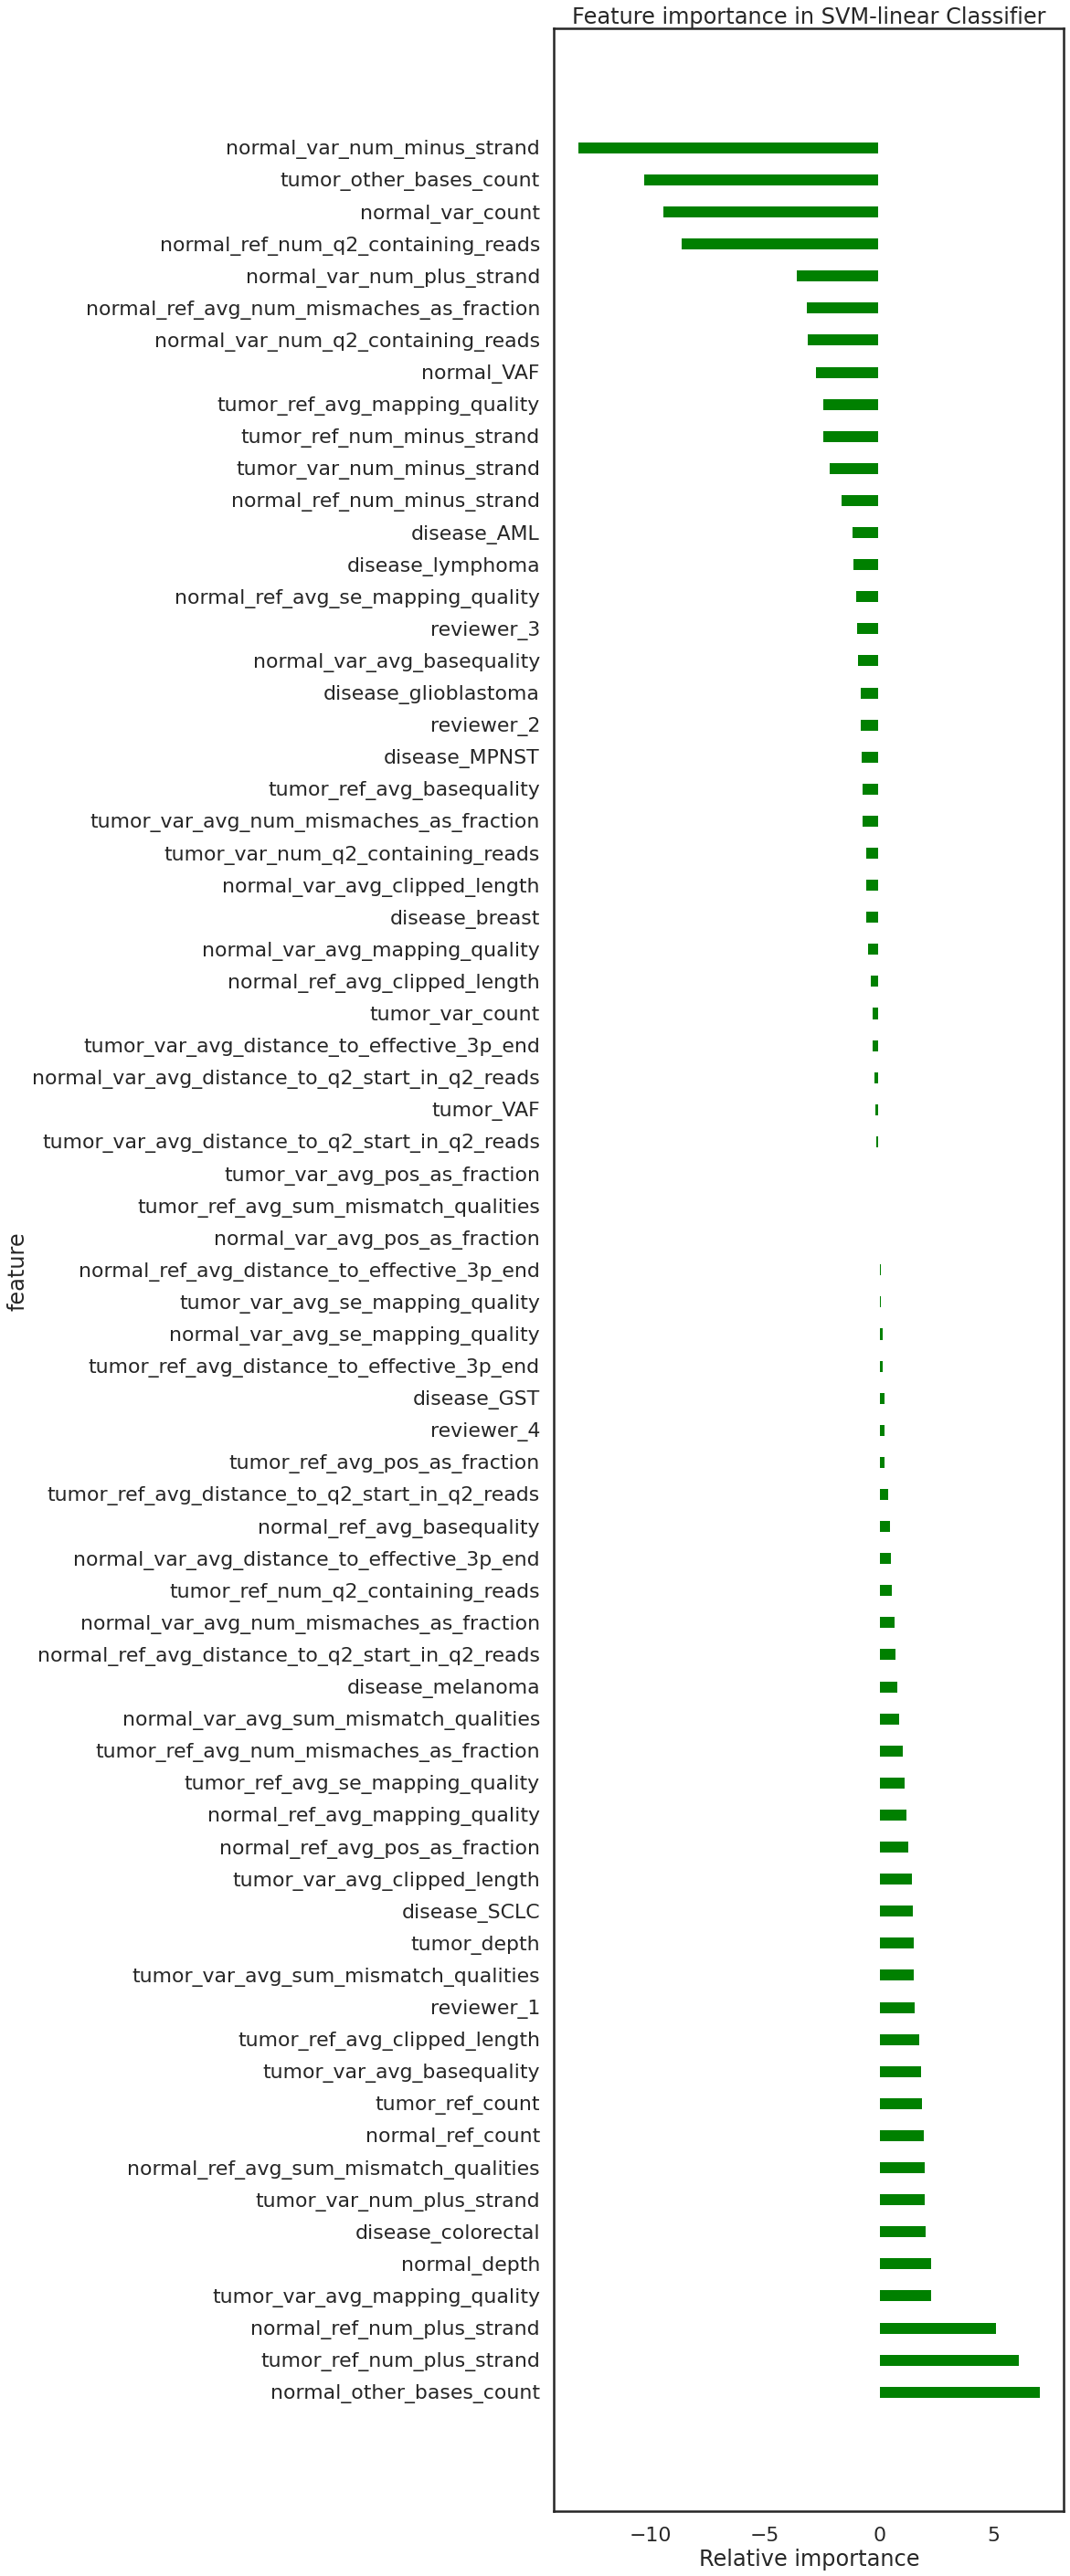

<Figure size 360x360 with 0 Axes>

In [0]:
# Fix which numbers correspond to which variables
feature_importances = pd.DataFrame(svm_model.best_estimator_.coef_[0],index =X_columns.columns,
columns=['importance']).sort_values('importance', ascending=False) 
feature_importances

import matplotlib. pyplot as plt
#modelname.feature_importance
x  = feature_importances.importance
col = feature_importances.importance.index

#plot
fig, ax = plt.subplots() 
width = 0.4 # the width of the bars 
ind = np.arange(len(x)) # the x locations for the groups
ax.barh(ind, x, width, color="green")
ax.set_yticks(ind+width/10)
ax.set_yticklabels(col, minor=False)
plt.title("Feature importance in SVM-linear Classifier")
plt.xlabel("Relative importance")
plt.ylabel("feature") 
plt.figure(figsize=(5,5))
fig.set_size_inches(10, 50, forward=True)

In [0]:
X_columns = training_data.drop('call', axis=1)
X_columns.columns

,disease_AML,disease_GST,disease_MPNST,disease_SCLC,disease_breast,disease_colorectal,disease_glioblastoma,disease_lymphoma,disease_melanoma,normal_VAF,normal_depth,normal_other_bases_count,normal_ref_avg_basequality,normal_ref_avg_clipped_length,normal_ref_avg_distance_to_effective_3p_end,normal_ref_avg_distance_to_q2_start_in_q2_reads,normal_ref_avg_mapping_quality,normal_ref_avg_num_mismaches_as_fraction,normal_ref_avg_pos_as_fraction,normal_ref_avg_se_mapping_quality,normal_ref_avg_sum_mismatch_qualities,normal_ref_count,normal_ref_num_minus_strand,normal_ref_num_plus_strand,normal_ref_num_q2_containing_reads,normal_var_avg_basequality,normal_var_avg_clipped_length,normal_var_avg_distance_to_effective_3p_end,normal_var_avg_distance_to_q2_start_in_q2_reads,normal_var_avg_mapping_quality,normal_var_avg_num_mismaches_as_fraction,normal_var_avg_pos_as_fraction,normal_var_avg_se_mapping_quality,normal_var_avg_sum_mismatch_qualities,normal_var_count,normal_var_num_minus_strand,normal_var_num_plus_strand,normal_var_num_q2_containing_reads,reviewer_1,reviewer_2,reviewer_3,reviewer_4,tumor_VAF,tumor_depth,tumor_other_bases_count,tumor_ref_avg_basequality,tumor_ref_avg_clipped_length,tumor_ref_avg_distance_to_effective_3p_end,tumor_ref_avg_distance_to_q2_start_in_q2_reads,tumor_ref_avg_mapping_quality,tumor_ref_avg_num_mismaches_as_fraction,tumor_ref_avg_pos_as_fraction,tumor_ref_avg_se_mapping_quality,tumor_ref_avg_sum_mismatch_qualities,tumor_ref_count,tumor_ref_num_minus_strand,tumor_ref_num_plus_strand,tumor_ref_num_q2_containing_reads,tumor_var_avg_basequality,tumor_var_avg_clipped_length,tumor_var_avg_distance_to_effective_3p_end,tumor_var_avg_distance_to_q2_start_in_q2_reads,tumor_var_avg_mapping_quality,tumor_var_avg_num_mismaches_as_fraction,tumor_var_avg_pos_as_fraction,tumor_var_avg_se_mapping_quality,tumor_var_avg_sum_mismatch_qualities,tumor_var_count,tumor_var_num_minus_strand,tumor_var_num_plus_strand,tumor_var_num_q2_containing_reads
fSsFJH1EY3AKAWF2 BER9Q2JBY3EPAWUcZUpOaAZCc0MRSRU=,1,0,0,0,0,0,0,0,0,0.000000,0.008968,0.000000,0.952927,0.792857,0.383838,0.278351,0.485333,0.090909,0.56,0.492973,0.114673,0.008974,0.010887,0.005475,0.004793,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1,0,0,0,0.266667,0.001308,0.000000,0.974390,0.793651,0.494949,0.571429,0.434167,0.08,0.57,0.261000,0.142866,0.001002,0.001105,0.000902,0.000794,0.894878,0.793651,0.414141,0.377551,0.192667,0.057692,0.62,0.140667,0.215676,0.000990,0.001075,0.000806,0.000735
fSsFJH1EY3AKAWF2 BEV9RGJDY3UABGEcYkpMaAJNdkcXSQY=,1,0,0,0,0,0,0,0,0,0.011494,0.019029,0.000000,0.864146,0.780635,0.484848,0.494845,0.983500,0.000000,0.50,0.994865,0.006272,0.018822,0.016935,0.017208,0.017117,0.878049,0.793651,0.363636,0.367347,1.000000,0.022727,0.76,0.616667,0.067925,0.001495,0.000000,0.003831,0.003497,1,0,0,0,0.584615,0.004250,0.000000,0.828780,0.739603,0.414141,0.438776,0.744833,0.12,0.46,0.548333,0.002040,0.001845,0.001243,0.002435,0.002185,0.883902,0.791508,0.474747,0.479592,1.000000,0.019231,0.51,0.614833,0.074597,0.007054,0.006450,0.007258,0.006860
fSsFJH1EY3AKAWF2 BEV9RGJDZ3oMAWMcYkpMbA1Bc0UTSQY=,1,0,0,0,0,0,0,0,0,0.000000,0.023185,0.000000,0.905366,0.790476,0.454545,0.443299,0.996333,0.000000,0.53,1.000000,0.002357,0.023200,0.023387,0.018772,0.017460,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1,0,0,0,0.417219,0.003291,0.000000,0.903902,0.789762,0.454545,0.397959,0.987500,0.00,0.53,0.612833,0.004759,0.002005,0.002624,0.001398,0.001350,0.871463,0.781587,0.444444,0.408163,1.000000,0.019231,0.53,0.616667,0.078946,0.003898,0.004192,0.003226,0.003553
fSsFJH1EY3AKAWF2 BEV9QmFCZXsLA2IcZElNbgxGcUN9SQY=,1,0,0,0,0,0,0,0,0,0.000000,0.001750,0.000000,0.838537,0.733175,0.494949,0.649485,0.731333,0.227273,0.56,0.797297,0.200983,0.001751,0.000403,0.002738,0.002396,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,0.0

In [0]:
X_columns.columns

NameError: ignored

In [0]:
svm_model.best_estimator_.columns

AttributeError: ignored

In [0]:
svm_model.best_estimator_.coef_

array([[-1.19361298e+00,  2.60446722e-01, -8.12694290e-01,
         1.49302257e+00, -6.10401104e-01,  2.06743235e+00,
        -8.40832071e-01, -1.17576168e+00,  8.12400477e-01,
        -2.80487403e+00,  2.32064850e+00,  7.07035295e+00,
         4.95206453e-01, -4.22633408e-01,  1.06003614e-01,
         7.33055611e-01,  1.24672873e+00, -3.22165999e+00,
         1.30595826e+00, -1.04751401e+00,  2.03591076e+00,
         1.98382922e+00, -1.66919963e+00,  5.16375863e+00,
        -8.69301158e+00, -9.55330906e-01, -6.18985468e-01,
         5.47781657e-01, -2.45137382e-01, -5.47029845e-01,
         7.07189903e-01,  5.56350808e-02,  1.75797533e-01,
         9.20898688e-01, -9.48374391e+00, -1.32108811e+01,
        -3.65741456e+00, -3.17842390e+00,  1.58571460e+00,
        -8.36800795e-01, -1.00936053e+00,  2.60446722e-01,
        -2.24591644e-01,  1.53171045e+00, -1.03240652e+01,
        -7.59438613e-01,  1.79179580e+00,  1.76100512e-01,
         4.47443352e-01, -2.47703350e+00,  1.06913243e+0

In [0]:

# Sum the feature importance metrics for one-hot encoded variables
# (Feature importance calculation in scikit-learn is outlined 
# here https://stackoverflow.com/a/15821880/3862525).
# Since the importances are calculated with the same denominator, summing is
# appropriate
def sum_features(feature_import, label):
    starts_with_label = feature_import.feature.str.startswith(label)
    return feature_import.importance[starts_with_label].sum()


# Create function to determine the feature importance 
def create_feature_importance_plot(trained_model, save_fp='SVM_feature_import.linear.pkl'):
    feature_import = pd.DataFrame([training_data.drop(['call'], axis=1).columns.values,trained_model.coef_[0]]).T
    feature_import.columns = ['feature', 'importance']
    summed_importances = []
    for label in ['disease', 'reviewer']:
        summed_importances.append([label, sum_features(feature_import, label)])
    summed_importances = pd.DataFrame(summed_importances, columns=['feature','importance'])
    feature_import.to_pickle(save_fp)
    #print(feature_import)
    feature_import.sort_values('importance', ascending=False, inplace=True)
    feature_import.replace({'feature':{'var':'variant','ref':'reference', 'avg':'average', '_se_':'_single_end_', '3p':'3_prime', '_':' '}}, regex=True, inplace=True)
    sns.barplot(y='feature', x='importance', data=feature_import.head(10), color='darkorange')
    plt.xlabel('Feature importance')
    plt.ylabel('Feature')
    plt.title('SVM  feature importance')

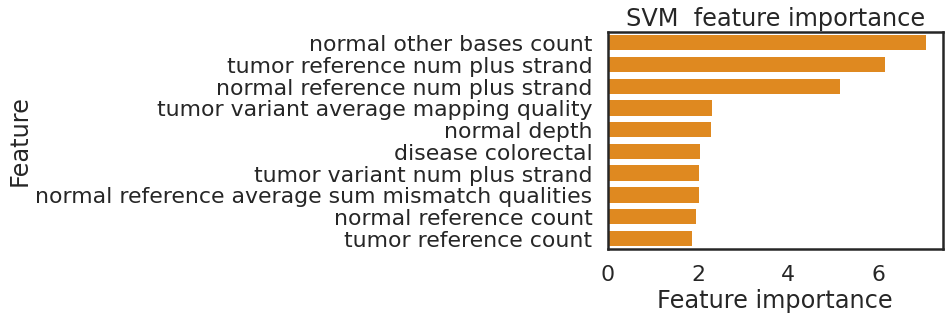

In [0]:
create_feature_importance_plot( pickle_model.best_estimator_)

# Naive Bayes Classifier

In [0]:
from sklearn.naive_bayes import GaussianNB
NB_classifier = GaussianNB()


In [0]:
NB_classifier.fit(X_train, Y_train)

GaussianNB(priors=None, var_smoothing=1e-09)

In [0]:
Y_pred  =NB_classifier.predict(X_test)

In [0]:

print_accuracy_and_classification_report(Y_test, Y_pred)

Cross validation accuracy:
	 0.7036215816703622

Cross validation classification report

              precision    recall  f1-score   support

           0       0.47      0.36      0.41      3454
           1       0.93      0.73      0.82      3961
           2       0.69      0.88      0.77      6115

    accuracy                           0.70     13530
   macro avg       0.70      0.66      0.67     13530
weighted avg       0.70      0.70      0.69     13530



In [0]:
NB_classifier.priors

In [0]:
# Set parameters for the Random Forest Model
kfold = KFold(n_splits=10, shuffle=True, random_state=seed)
probabilities = cross_val_predict(NB_classifier, X, Y, cv=kfold, method='predict_proba')

In [0]:
# Turn probabilities into a numpy array
predicted = np.array([list(a).index(max(list(a))) for a in list(probabilities)])


In [0]:
print_accuracy_and_classification_report(Y, predicted)

Cross validation accuracy:
	 0.7059512195121951

Cross validation classification report

              precision    recall  f1-score   support

           0       0.49      0.37      0.42     10643
           1       0.92      0.73      0.81     11976
           2       0.69      0.88      0.78     18381

    accuracy                           0.71     41000
   macro avg       0.70      0.66      0.67     41000
weighted avg       0.71      0.71      0.70     41000



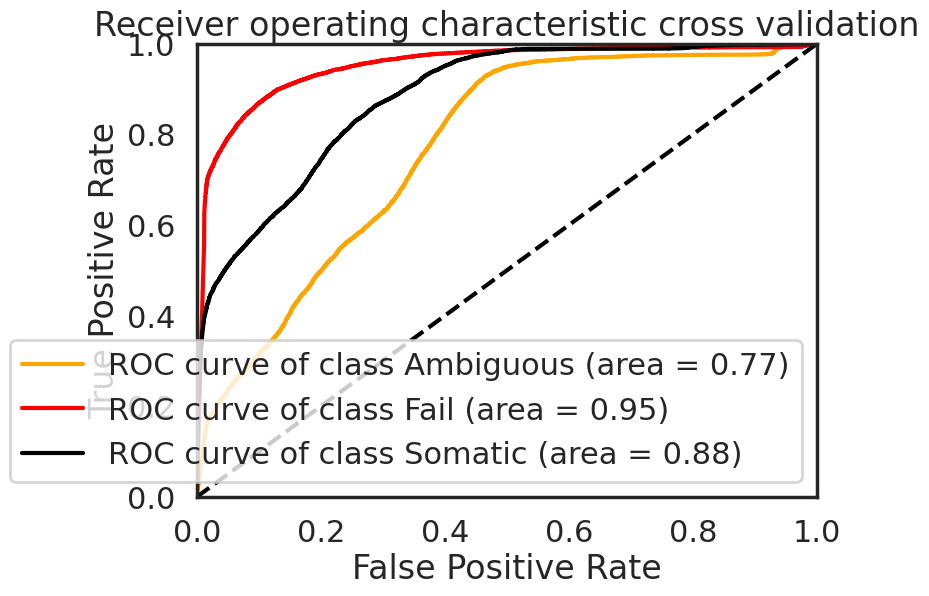

In [0]:
# Plot AUC curves for Logistic Regression Model
class_lookup = {0: 'Ambiguous', 1: 'Fail', 2: 'Somatic'}
fig, ax = plt.subplots(figsize=(8,6),dpi=100)
create_roc_curve( pd.get_dummies(three_class.call).astype(float).values, probabilities, class_lookup, 'Receiver operating'
                 ' characteristic cross validation', ax=ax)

confidence intervals +-:  [0.00122473 0.01970287 0.02404725 0.02759058 0.02960576 0.02920239
 0.02711238 0.02344885 0.01930217 0.00220823]


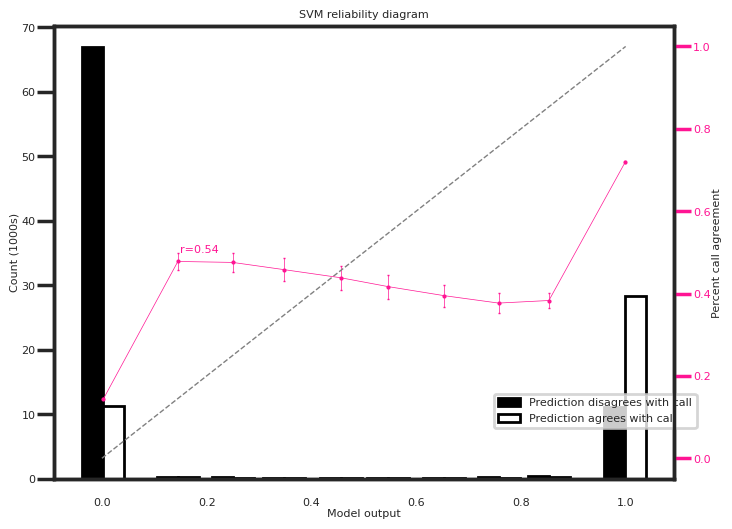

In [0]:
# Plot Reliability Diagrams for Logistic Regression Model
fig, ax = plt.subplots(figsize=(8,6),dpi=100)
lgd = create_reliability_diagram(probabilities,  pd.get_dummies(three_class.call).astype(float)
.values,['Ambiguous','Fail','Somatic'], 'deeppink', 'SVM reliability diagram',
                           ax, True, True, True)
lgd.set_bbox_to_anchor((0.7, .1))

# KNN

# NN

# Three Class - Model evaluation